In [1]:
import itertools
import random
import math
import scipy.stats as ss
import numpy as np
import dendropy
from dendropy.calculate import treemeasure


In [2]:
import skbio
from skbio import DistanceMatrix
from skbio.tree import nj

In [3]:
def p_delta_change(n_states, l, change: bool):
    if not change:
        p_out = 1 / n_states + (n_states - 1) / n_states * math.exp(- (n_states - 1) * l)
    else:
        p_out = 1 / n_states - math.exp(- (n_states - 1) * l) / n_states
    return p_out

def simulate_cn_seq(prev_cn, n_states, l, alpha=1.):
    node_cn = np.empty_like(prev_cn)
    pdd = p_delta_change(n_states, alpha * l, change=False)
    u = random.random()
    if u < pdd:
        node_cn[0] = prev_cn[0]
    else:
        node_cn[0] = random.choice([j for j in range(n_states) if j != prev_cn[0]])

    for m in range(1, len(prev_cn)):
        u = random.random()
        no_change_cn = prev_cn[m] - prev_cn[m-1] + node_cn[m-1]
        if 0 <= no_change_cn < n_states:
            if u < pdd:
                node_cn[m] = no_change_cn
            else:
                node_cn[m] = random.choice([j for j in range(n_states) if j != no_change_cn])
        else:
            node_cn[m] = random.choice([j for j in range(n_states)])
    return node_cn

def simulate_cn(tree, n_sites, n_states, alpha=1.):
    cn = np.empty((len(tree.nodes()), n_sites))
    cn[0, :] = 2
    assert tree.seed_node.label is not None
    for n in tree.preorder_node_iter():
        if n.label != 0:
            cn[n.label] = simulate_cn_seq(cn[n.parent_node.label], n_states, n.edge_length, alpha=alpha)
    return cn

def emit_normalized_obs(cn_seq, mu=1.0, scale=1.0):
    eps = ss.norm(loc=0., scale=scale).rvs(size=len(cn_seq))
    return np.clip(cn_seq / mu + eps, a_min=0., a_max=None)

def emit_raw_obs(cn_seq, lam=100.):
    return ss.poisson.rvs(mu=np.clip(cn_seq, a_min=.01, a_max=None) * lam, size=len(cn_seq))

def label_tree(tree):
    for i, n in enumerate(tree.preorder_node_iter()):
        n.label = i

def rand_dataset(n_cells: int, n_states: int, n_sites: int, alpha=0.02, obs_type='norm') -> dict:
    tree = dendropy.treesim.treesim.birth_death_tree(birth_rate=0.9, death_rate=0.4, num_extant_tips=n_cells)
    label_tree(tree)
    cn = simulate_cn(tree, n_sites, n_states, alpha=alpha)
    obs = np.empty((n_sites, n_cells))
    tax_id_map = {}
    for i, t in enumerate(tree.leaf_node_iter()):
        tax_id_map[t.taxon] = i
        if obs_type == 'pois':
            obs[:, i] = emit_raw_obs(cn[t.label])
        elif obs_type == 'norm':
            obs[:, i] = emit_normalized_obs(cn[t.label], scale=.7)
    data = {
        'obs': obs,
        'tree': tree,
        'cn': cn,
        'tax_id_map': tax_id_map
    }
    return data

def get_distance_matrix(tree):
    taxa = list(tree.taxon_namespace)
    pdc = tree.phylogenetic_distance_matrix()
    n = len(taxa)
    dist_matrix = np.zeros((n, n))
    for i, t1 in enumerate(taxa):
        for j, t2 in enumerate(taxa):
            if i != j:
                dist_matrix[i, j] = pdc(t1, t2)
    return dist_matrix

In [4]:
# Generate dataset

data = rand_dataset(20, 8, 10)
tree = data['tree']


In [5]:
# Calculate the initial distance matrix

initial_dist_matrix = get_distance_matrix(tree)
print("Initial Distance Matrix:")
print(initial_dist_matrix)


Initial Distance Matrix:
[[0.         0.         4.4414224  3.96763206 4.4414224  4.4414224
  4.4414224  0.07141801 4.4414224  4.4414224  4.4414224  4.4414224
  4.4414224  4.4414224  4.4414224  3.96763206 4.4414224  3.96763206
  4.4414224  3.85798525]
 [0.         0.         4.4414224  3.96763206 4.4414224  4.4414224
  4.4414224  0.07141801 4.4414224  4.4414224  4.4414224  4.4414224
  4.4414224  4.4414224  4.4414224  3.96763206 4.4414224  3.96763206
  4.4414224  3.85798525]
 [4.4414224  4.4414224  0.         4.4414224  2.17343077 2.17343077
  2.17343077 4.4414224  2.17343077 2.17343077 2.17343077 2.17343077
  0.42397401 2.66351124 2.66351124 4.4414224  2.17343077 4.4414224
  2.17343077 4.4414224 ]
 [3.96763206 3.96763206 4.4414224  0.         4.4414224  4.4414224
  4.4414224  3.96763206 4.4414224  4.4414224  4.4414224  4.4414224
  4.4414224  4.4414224  4.4414224  1.1481317  4.4414224  1.53651053
  4.4414224  3.96763206]
 [4.4414224  4.4414224  2.17343077 4.4414224  0.         1.9262858

In [6]:
initial_dist_matrix

array([[0.        , 0.        , 4.4414224 , 3.96763206, 4.4414224 ,
        4.4414224 , 4.4414224 , 0.07141801, 4.4414224 , 4.4414224 ,
        4.4414224 , 4.4414224 , 4.4414224 , 4.4414224 , 4.4414224 ,
        3.96763206, 4.4414224 , 3.96763206, 4.4414224 , 3.85798525],
       [0.        , 0.        , 4.4414224 , 3.96763206, 4.4414224 ,
        4.4414224 , 4.4414224 , 0.07141801, 4.4414224 , 4.4414224 ,
        4.4414224 , 4.4414224 , 4.4414224 , 4.4414224 , 4.4414224 ,
        3.96763206, 4.4414224 , 3.96763206, 4.4414224 , 3.85798525],
       [4.4414224 , 4.4414224 , 0.        , 4.4414224 , 2.17343077,
        2.17343077, 2.17343077, 4.4414224 , 2.17343077, 2.17343077,
        2.17343077, 2.17343077, 0.42397401, 2.66351124, 2.66351124,
        4.4414224 , 2.17343077, 4.4414224 , 2.17343077, 4.4414224 ],
       [3.96763206, 3.96763206, 4.4414224 , 0.        , 4.4414224 ,
        4.4414224 , 4.4414224 , 3.96763206, 4.4414224 , 4.4414224 ,
        4.4414224 , 4.4414224 , 4.4414224 , 4

In [7]:
type(initial_dist_matrix)

numpy.ndarray

In [8]:
ids = []
for i, leaf in enumerate(tree.leaf_node_iter(), start=1):
    label = f"T{i}: {leaf.taxon.label}"
    ids.append(label)

In [9]:
print("List of T_1 to T_ncells:")
for id_label in ids:
    print(id_label)

List of T_1 to T_ncells:
T1: T15
T2: T14
T3: T17
T4: T7
T5: T6
T6: T12
T7: T19
T8: T10
T9: T11
T10: T5
T11: T9
T12: T13
T13: T3
T14: T18
T15: T4
T16: T16
T17: T8
T18: T1
T19: T2
T20: T20


In [10]:
# Prepare the labels for scikit-bio

labels = [f"T_{i+1}" for i in range(len(tree.leaf_nodes()))]


In [11]:
labels

['T_1',
 'T_2',
 'T_3',
 'T_4',
 'T_5',
 'T_6',
 'T_7',
 'T_8',
 'T_9',
 'T_10',
 'T_11',
 'T_12',
 'T_13',
 'T_14',
 'T_15',
 'T_16',
 'T_17',
 'T_18',
 'T_19',
 'T_20']

In [12]:
# Create a DistanceMatrix -> scikit-bio
dm_skbio = DistanceMatrix(initial_dist_matrix, labels)

In [13]:
# Perform NJ algorithm using scikit-bio

nj_tree = nj(dm_skbio)
print(nj_tree)


(((T_13:0.211987,T_3:0.211987):0.874728,((T_15:0.012347,T_14:0.012347):1.319408,((T_18:0.768255,(T_16:0.574066,T_4:0.574066):0.194189):1.215561,(T_20:1.928993,(T_8:0.035709,(T_2:0.0,T_1:0.0):0.035709):1.893284):0.054823):1.125851):0.24504):0.096896,((T_9:0.136356,(T_11:0.098803,T_5:0.098803):0.037553):0.826787,((T_7:0.171247,T_6:0.171247):0.292869,(T_10:0.365197,(T_19:0.270025,T_12:0.270025):0.095171):0.098919):0.499027):0.026677,T_17:0.98982);



In [19]:
# Compare the NJ tree to the initial tree
nj_tree_newick = nj_tree.write('NJTree')
print("NJ Tree Newick format:")
print(nj_tree_newick)

NJ Tree Newick format:
NJTree


In [14]:
NJ_DM= DistanceMatrix(initial_dist_matrix, ids)

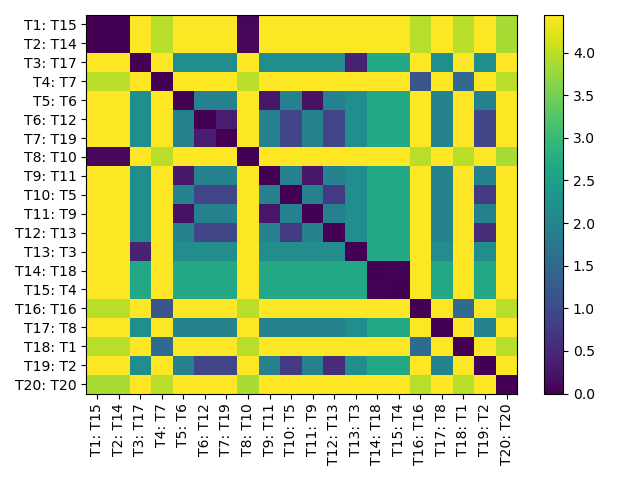

In [15]:
NJ_DM

In [24]:
nj_labels = [node.name for node in nj_tree.tips()]


In [25]:
nj_dist_matrix = nj_tree_skbio.tip_tip_distances(nj_labels)


In [28]:
# Calculate the distance matrix for the NJ tree
nj_tree_skbio = skbio.TreeNode.read(nj_tree_newick)
nj_dist_matrix = nj_tree_skbio.tip_tip_distances(nj_labels)
print("NJ Distance Matrix:")
print(nj_dist_matrix)


NJ Distance Matrix:
20x20 distance matrix
IDs:
'T 13', 'T 3', 'T 15', 'T 14', 'T 18', 'T 16', 'T 4', 'T 20', 'T 8', 'T 2', ...
Data:
[[0.       0.423974 2.66351  2.66351  4.441422 4.441422 4.441422 4.441422
  4.441422 4.441422 4.441422 2.173431 2.173431 2.173431 2.173431 2.173431
  2.173431 2.17343  2.17343  2.173431]
 [0.423974 0.       2.66351  2.66351  4.441422 4.441422 4.441422 4.441422
  4.441422 4.441422 4.441422 2.173431 2.173431 2.173431 2.173431 2.173431
  2.173431 2.17343  2.17343  2.173431]
 [2.66351  2.66351  0.       0.024694 4.441422 4.441422 4.441422 4.441422
  4.441422 4.441422 4.441422 2.663511 2.663511 2.663511 2.663511 2.663511
  2.663511 2.66351  2.66351  2.663511]
 [2.66351  2.66351  0.024694 0.       4.441422 4.441422 4.441422 4.441422
  4.441422 4.441422 4.441422 2.663511 2.663511 2.663511 2.663511 2.663511
  2.663511 2.66351  2.66351  2.663511]
 [4.441422 4.441422 4.441422 4.441422 0.       1.53651  1.53651  3.967632
  3.967632 3.967632 3.967632 4.441423 4.44142

In [30]:
nj_dist_matrix_array = nj_dist_matrix.to_data_frame().to_numpy()


In [31]:
# Compare the two distance matrices
difference = np.abs(initial_dist_matrix - nj_dist_matrix_array)
print("Difference between Initial and NJ Distance Matrices:")
print(difference)

# List T_1 until T_n

Difference between Initial and NJ Distance Matrices:
[[0.00000000e+00 4.23974000e-01 1.77791240e+00 1.30412206e+00
  4.00663767e-07 4.00663767e-07 4.00663767e-07 4.37000399e+00
  4.00663767e-07 4.00663767e-07 4.00663767e-07 2.26799140e+00
  2.26799140e+00 2.26799140e+00 2.26799140e+00 1.79420106e+00
  2.26799140e+00 1.79420206e+00 2.26799240e+00 1.68455425e+00]
 [4.23974000e-01 0.00000000e+00 1.77791240e+00 1.30412206e+00
  4.00663767e-07 4.00663767e-07 4.00663767e-07 4.37000399e+00
  4.00663767e-07 4.00663767e-07 4.00663767e-07 2.26799140e+00
  2.26799140e+00 2.26799140e+00 2.26799140e+00 1.79420106e+00
  2.26799140e+00 1.79420206e+00 2.26799240e+00 1.68455425e+00]
 [1.77791240e+00 1.77791240e+00 0.00000000e+00 4.41672840e+00
  2.26799123e+00 2.26799123e+00 2.26799123e+00 4.00663766e-07
  2.26799123e+00 2.26799123e+00 2.26799123e+00 4.90080225e-01
  2.23953699e+00 2.41688864e-07 2.41688864e-07 1.77791140e+00
  4.90080225e-01 1.77791240e+00 4.90079225e-01 1.77791140e+00]
 [1.30412206e+

In [16]:
# Perform NJ test and generate a new tree
taxa = tree.taxon_namespace
dm = dendropy.PhylogeneticDistanceMatrix()

In [12]:
nj_tree = nj(NJ_DM)

NewickFormatError: Could not read length as numeric type: T8.

In [6]:
nj_tree = dm.nj_tree()
nj_tree.encode_bipartitions()

IndexError: list index out of range

In [10]:
for i, taxon1 in enumerate(taxa):
    for j, taxon2 in enumerate(taxa):
        if i < j:
            dm(taxon1, taxon2, initial_dist_matrix[i, j])


TypeError: PhylogeneticDistanceMatrix.__call__() takes 3 positional arguments but 4 were given

In [ ]:
# Compare the two distance matrices
difference = np.abs(initial_dist_matrix - nj_dist_matrix)
print("Difference between Initial and NJ Distance Matrices:")
print(difference)